# PPC5: Solução da Equação de Blasius pelo Método do Tiro e RK4

Este notebook implementa a solução numérica da equação de Blasius usando o **Método do Tiro** combinado com o método de **Runge-Kutta de 4ª ordem**.

#Aluno: Felipe Tavares Loureiro  
#Professor: Prof. Dr. Rafael Gabler Gontijo  
#Disciplina: ENM0227 - Cálculo Numérico Aplicado  
#Semestre: 2026.1

## Objetivos

1. Resolver numericamente a equação de Blasius:

$$
f''' + \frac{1}{2}ff'' = 0
$$

2. Transformar o problema de valor de contorno em um problema de valor inicial pelo Método do Tiro.
3. Ajustar numericamente o parâmetro desconhecido $s=f''(0)$.
4. Integrar o sistema de EDOs usando Runge-Kutta de quarta ordem.
5. Salvar os resultados em um arquivo `.dat` contendo $\eta$, $f$, $f'$ e $f''$.
6. Plotar os perfis de similaridade.
7. Calcular o coeficiente local de atrito na parede.
8. Determinar numericamente $\eta_{99}$ e comparar com a correlação clássica da literatura.


# Formulação do problema

A equação de Blasius é dada por:

$$
f''' + \frac{1}{2}ff'' = 0
$$

com as condições de contorno:

$$
f(0)=0, \qquad f'(0)=0, \qquad f'(\infty)=1.
$$

Como não é possível integrar numericamente até o infinito, usa-se um valor suficientemente grande $\eta_{max}$ e impõe-se:

$$
f'(\eta_{max}) \approx 1.
$$

Para transformar a equação de terceira ordem em um sistema de primeira ordem, define-se:

$$
y_1=f, \qquad y_2=f', \qquad y_3=f''.
$$

Assim:

$$
\frac{dy_1}{d\eta}=y_2
$$

$$
\frac{dy_2}{d\eta}=y_3
$$

$$
\frac{dy_3}{d\eta}=-\frac{1}{2}y_1y_3
$$

No Método do Tiro, o valor desconhecido é:

$$
s=f''(0).
$$

As condições iniciais usadas na integração são:

$$
y_1(0)=0, \qquad y_2(0)=0, \qquad y_3(0)=s.
$$

O parâmetro $s$ é ajustado até que:

$$
|f'(\eta_{max})-1|<tol.
$$


# Imports e funções auxiliares

Nesta célula são definidas as funções usadas na solução numérica. A integração por RK4 é implementada diretamente, sem uso de bibliotecas prontas de integração numérica.

In [1]:
from math import sqrt
import matplotlib.pyplot as plt


# Convenções usadas no notebook:
# eta     : variável de similaridade
# f       : função de Blasius
# fp      : primeira derivada de f, isto é, f'
# fpp     : segunda derivada de f, isto é, f''
# s       : parâmetro de tiro, definido como f''(0)
# h       : passo de integração em eta
# etamax  : valor máximo de eta usado para aproximar infinito
# Rex     : número de Reynolds local


def derivadas_blasius(y):
    """
    Calcula as derivadas do sistema de EDOs equivalente à equação de Blasius.

    Variáveis:
    y[0] = f
    y[1] = f'
    y[2] = f''

    Sistema:
    dy1/deta = y2
    dy2/deta = y3
    dy3/deta = -0.5*y1*y3
    """

    f = y[0]
    fp = y[1]
    fpp = y[2]

    dy1 = fp
    dy2 = fpp
    dy3 = -0.5*f*fpp

    return [dy1, dy2, dy3]


def rk4_blasius(s, h, etamax):
    """
    Integra o sistema de EDOs da equação de Blasius usando RK4.

    Para cada chute s = f''(0), o problema de valor de contorno original
    passa a ser tratado como um problema de valor inicial.

    Entrada:
    s      : chute para f''(0)
    h      : passo de integração
    etamax : valor máximo de eta

    Saída:
    listas contendo eta, f, f' e f''.
    """

    # Condições iniciais do PVI gerado pelo Método do Tiro
    eta = 0.0
    y = [0.0, 0.0, s]

    # Listas para armazenar os resultados calculados
    lista_eta = [eta]
    lista_f = [y[0]]
    lista_fp = [y[1]]
    lista_fpp = [y[2]]

    while eta < etamax - 1e-14:

        # Ajuste do último passo para encerrar exatamente em etamax
        if eta + h > etamax:
            h_atual = etamax - eta
        else:
            h_atual = h

        # k1: inclinação no início do passo
        k1 = derivadas_blasius(y)

        # k2: inclinação estimada no meio do passo usando k1
        y_aux = [y[i] + 0.5*h_atual*k1[i] for i in range(3)]
        k2 = derivadas_blasius(y_aux)

        # k3: nova inclinação estimada no meio do passo usando k2
        y_aux = [y[i] + 0.5*h_atual*k2[i] for i in range(3)]
        k3 = derivadas_blasius(y_aux)

        # k4: inclinação estimada no final do passo usando k3
        y_aux = [y[i] + h_atual*k3[i] for i in range(3)]
        k4 = derivadas_blasius(y_aux)

        # Atualização simultânea das três variáveis pelo RK4
        for i in range(3):
            y[i] = y[i] + (h_atual/6.0)*(k1[i] + 2.0*k2[i] + 2.0*k3[i] + k4[i])

        # Avança a variável independente
        eta = eta + h_atual

        # Armazena os resultados do passo atual
        lista_eta.append(eta)
        lista_f.append(y[0])
        lista_fp.append(y[1])
        lista_fpp.append(y[2])

    return lista_eta, lista_f, lista_fp, lista_fpp


def erro_tiro(s, h, etamax):
    """
    Calcula o erro do Método do Tiro.

    A condição desejada é:
        f'(etamax) = 1

    Portanto, define-se:
        erro = f'(etamax) - 1
    """

    eta, f, fp, fpp = rk4_blasius(s, h, etamax)

    return fp[-1] - 1.0


def metodo_do_tiro(s0, h, etamax, tol, maxit):
    """
    Ajusta o valor de s = f''(0) usando o Método da Secante.

    O processo é repetido até que:
        abs(f'(etamax)-1) < tol

    ou até que o número máximo de iterações seja atingido.
    """

    if h <= 0.0:
        raise ValueError("O passo h deve ser positivo.")

    if etamax <= 0.0:
        raise ValueError("etamax deve ser positivo.")

    if tol <= 0.0:
        raise ValueError("A tolerância deve ser positiva.")

    # Primeiro chute informado pelo usuário
    sold = s0

    # Segundo chute gerado automaticamente a partir do primeiro
    snew = 1.1*s0

    # Evita dois chutes iguais caso s0 seja zero
    if snew == sold:
        snew = sold + 0.1

    # Erros associados aos dois primeiros chutes
    errold = erro_tiro(sold, h, etamax)
    erronew = erro_tiro(snew, h, etamax)

    it = 0

    while abs(erronew) > tol and it < maxit:

        denominador = erronew - errold

        # Proteção contra divisão por número muito pequeno
        if abs(denominador) < 1e-15:
            print("Aviso: denominador muito pequeno no Método da Secante.")
            break

        # Fórmula da secante para atualizar o chute de s
        snext = snew - erronew*(snew - sold)/denominador

        # Atualiza os valores antigos
        sold = snew
        errold = erronew

        # Atualiza o novo chute
        snew = snext
        erronew = erro_tiro(snew, h, etamax)

        it = it + 1

    # Integra uma última vez usando o valor convergido de s
    eta, f, fp, fpp = rk4_blasius(snew, h, etamax)

    return eta, f, fp, fpp, snew, erronew, it


def achar_eta99(eta, fp):
    """
    Determina eta99 por interpolação linear.

    eta99 é definido pela condição:
        f'(eta99) = 0.99
    """

    for i in range(1, len(eta)):

        if fp[i] >= 0.99:

            eta1 = eta[i-1]
            eta2 = eta[i]

            fp1 = fp[i-1]
            fp2 = fp[i]

            if abs(fp2 - fp1) < 1e-15:
                return eta2

            eta99 = eta1 + (0.99 - fp1)*(eta2 - eta1)/(fp2 - fp1)

            return eta99

    return None


def salvar_dat(nome, eta, f, fp, fpp):
    """
    Salva os resultados em arquivo .dat.

    As colunas são:
        eta   f   fp   fpp

    O separador usado é espaço, formato comum para pós-processamento numérico.
    """

    arquivo = open(nome, "w")

    arquivo.write("# eta f fp fpp\n")

    for i in range(len(eta)):
        arquivo.write(f"{eta[i]:.10e} {f[i]:.10e} {fp[i]:.10e} {fpp[i]:.10e}\n")

    arquivo.close()


# Parâmetros numéricos da simulação

Nesta etapa, definem-se os parâmetros numéricos necessários para a simulação:

- chute inicial para $s=f''(0)$;
- passo de integração $h=\Delta\eta$;
- valor máximo de $\eta$;
- tolerância de convergência;
- número máximo de iterações do Método do Tiro;
- número de Reynolds local $Re_x$.

Os valores abaixo foram escolhidos por serem suficientemente bons para obter uma solução próxima dos valores clássicos da literatura.


In [2]:
# Parâmetros da simulação principal
s0 = 0.3
h = 0.01
etamax = 8.0
tol = 1e-10
maxit = 30
Rex = 100000.0

# Solução do problema pelo Método do Tiro + RK4
eta, f, fp, fpp, s, errofinal, it = metodo_do_tiro(s0, h, etamax, tol, maxit)

# Determinação de eta99 e cálculo do coeficiente de atrito
eta99 = achar_eta99(eta, fp)
Cf = 2.0*s/sqrt(Rex)

print("="*60)
print("PARAMETROS USADOS")
print("="*60)
print("s0:", s0)
print("h:", h)
print("etamax:", etamax)
print("tol:", tol)
print("maxit:", maxit)
print("Rex:", Rex)

print("="*60)
print("RESULTADOS")
print("="*60)
print("f''(0) convergido:", s)
print("numero de iteracoes:", it)
print("erro final:", errofinal)
print("f'(etamax):", fp[-1])
print("Cf:", Cf)

if eta99 is not None:
    print("eta99:", eta99)
    print("Cdelta:", eta99)
    print("delta/x:", eta99/sqrt(Rex))
else:
    print("eta99 nao encontrado. Aumente o valor de etamax.")

print("="*60)


PARAMETROS USADOS
s0: 0.3
h: 0.01
etamax: 8.0
tol: 1e-10
maxit: 30
Rex: 100000.0
RESULTADOS
f''(0) convergido: 0.3320591917351754
numero de iteracoes: 3
erro final: -1.224020884649235e-12
f'(etamax): 0.999999999998776
Cf: 0.002100126727755427
eta99: 4.909781706796783
Cdelta: 4.909781706796783
delta/x: 0.01552609300770684


## Comentário dos resultados principais

O Método do Tiro ajustou o valor de $s=f''(0)$ até que a condição distante da parede fosse satisfeita numericamente.

A condição de convergência adotada foi:

$$
|f'(\eta_{max})-1|<tol.
$$

Com os parâmetros usados, o valor de $f'(\eta_{max})$ ficou muito próximo de 1, indicando que a condição de contorno distante da parede foi bem aproximada.

O valor obtido para $f''(0)$ também ficou próximo do valor clássico da literatura:

$$
f''(0) \approx 0.332057.
$$

O coeficiente local de atrito foi calculado por:

$$
C_f=\frac{2f''(0)}{\sqrt{Re_x}}.
$$

Além disso, a posição $\eta_{99}$ foi determinada pela condição:

$$
f'(\eta_{99})=0.99.
$$

Como $f'(\eta)=u/U_\infty$, essa posição representa o ponto em que a velocidade local atinge 99% da velocidade do escoamento livre.


# Arquivo de saída `.dat`

O programa salva os resultados em um arquivo chamado `blasius_resultados.dat`. O arquivo contém quatro colunas separadas por espaço:

```text
eta   f   fp   fpp
```

Esse formato é adequado para pós-processamento posterior em Python, Fortran, GNUplot, MATLAB ou outro programa de análise numérica.

In [3]:
nome_arquivo = "blasius_resultados.dat"

salvar_dat(nome_arquivo, eta, f, fp, fpp)

print("="*60)
print("Arquivo salvo:", nome_arquivo)
print("Colunas: eta f fp fpp")
print("="*60)


Arquivo salvo: blasius_resultados.dat
Colunas: eta f fp fpp


# Perfis de similaridade

Nesta etapa, são plotados os perfis:

$$
f(\eta), \qquad f'(\eta), \qquad f''(\eta).
$$

O perfil $f'(\eta)$ é particularmente importante porque representa a razão entre a velocidade local e a velocidade do escoamento livre:

$$
f'(\eta)=\frac{u}{U_\infty}.
$$


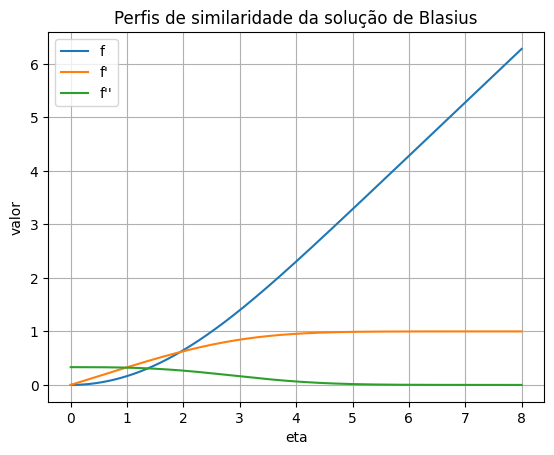

In [4]:
plt.plot(eta, f, label="f")
plt.plot(eta, fp, label="f'")
plt.plot(eta, fpp, label="f''")

plt.xlabel("eta")
plt.ylabel("valor")
plt.title("Perfis de similaridade da solução de Blasius")
plt.grid()
plt.legend()
plt.show()


## Análise dos perfis

O perfil $f(\eta)$ cresce continuamente ao longo do domínio, como esperado para a função de similaridade da solução de Blasius.

O perfil $f'(\eta)$ começa em zero, satisfazendo a condição de não deslizamento na parede:

$$
f'(0)=0.
$$

À medida que $\eta$ aumenta, $f'(\eta)$ tende a 1, indicando que a velocidade local se aproxima da velocidade do escoamento livre.

O perfil $f''(\eta)$ está associado ao gradiente de velocidade. Seu valor máximo ocorre na parede e é justamente o parâmetro determinado pelo Método do Tiro:

$$
f''(0)=s.
$$

Esse valor aparece diretamente no cálculo do coeficiente local de atrito.


# Comparação com a literatura

Nesta célula, compara-se o valor numérico de $f''(0)$ com o valor clássico da literatura. Também se compara $C_\delta = \eta_{99}$ com o valor aproximado usado na correlação clássica da espessura da camada limite.

In [5]:
valor_classico_fpp0 = 0.332057
valor_classico_Cdelta = 4.92

erro_abs_fpp0 = abs(s - valor_classico_fpp0)
erro_rel_fpp0 = erro_abs_fpp0/valor_classico_fpp0

print("="*60)
print("COMPARACAO COM A LITERATURA")
print("="*60)
print("f''(0) numerico:", s)
print("f''(0) classico:", valor_classico_fpp0)
print("erro absoluto:", erro_abs_fpp0)
print("erro relativo:", erro_rel_fpp0)

if eta99 is not None:
    erro_abs_Cdelta = abs(eta99 - valor_classico_Cdelta)
    erro_rel_Cdelta = erro_abs_Cdelta/valor_classico_Cdelta

    print("="*60)
    print("Cdelta numerico:", eta99)
    print("Cdelta classico:", valor_classico_Cdelta)
    print("erro absoluto:", erro_abs_Cdelta)
    print("erro relativo:", erro_rel_Cdelta)

print("="*60)


COMPARACAO COM A LITERATURA
f''(0) numerico: 0.3320591917351754
f''(0) classico: 0.332057
erro absoluto: 2.191735175405274e-06
erro relativo: 6.600478759385509e-06
Cdelta numerico: 4.909781706796783
Cdelta classico: 4.92
erro absoluto: 0.010218293203217321
erro relativo: 0.002076888862442545


## Comentário da comparação com a literatura

O valor numérico obtido para $f''(0)$ ficou muito próximo do valor clássico:

$$
f''(0) \approx 0.332057.
$$

Isso indica que o Método do Tiro encontrou corretamente o valor inicial de $f''(0)$ necessário para que a solução satisfaça a condição $f'(\eta_{max})\approx 1$.

O valor de $C_\delta=\eta_{99}$ também ficou próximo de 4.92, valor associado à correlação clássica:

$$
\frac{\delta}{x}=\frac{4.92}{\sqrt{Re_x}}.
$$

Pequenas diferenças são esperadas porque o domínio numérico usa um valor finito de $\eta_{max}$ no lugar do infinito e porque $\eta_{99}$ é obtido por interpolação em uma malha discreta.


# Análise da influência de $h$ e de $\eta_{max}$

Para discutir as fontes de erro numérico, é útil observar como o valor obtido de $f''(0)$ muda quando se altera o passo de integração e o tamanho do domínio computacional.

In [6]:
valores_h = [0.05, 0.02, 0.01, 0.005]
valores_etamax = [6.0, 8.0, 10.0]

print("="*90)
print(f"{'h':>10} {'etamax':>10} {'fpp0':>20} {'erro final':>20} {'iteracoes':>12}")
print("="*90)

for h_teste in valores_h:
    for etamax_teste in valores_etamax:

        eta_t, f_t, fp_t, fpp_t, s_t, erro_t, it_t = metodo_do_tiro(
            s0=s0,
            h=h_teste,
            etamax=etamax_teste,
            tol=tol,
            maxit=maxit
        )

        print(f"{h_teste:>10.5f} {etamax_teste:>10.2f} {s_t:>20.12f} {erro_t:>20.10e} {it_t:>12}")

print("="*90)


         h     etamax                 fpp0           erro final    iteracoes
   0.05000       6.00       0.332565932688    -3.2325253585e-12            3
   0.05000       8.00       0.332059192322    -1.2213563494e-12            3
   0.05000      10.00       0.332057337757    -1.2114753645e-12            3
   0.02000       6.00       0.332565931239    -3.2307490017e-12            3
   0.02000       8.00       0.332059191750    -1.2201351041e-12            3
   0.02000      10.00       0.332057337218    -1.2123635429e-12            3
   0.01000       6.00       0.332565931204    -3.2327474031e-12            3
   0.01000       8.00       0.332059191735    -1.2240208846e-12            3
   0.01000      10.00       0.332057337204    -1.2124745652e-12            3
   0.00500       6.00       0.332565931202    -3.2340796707e-12            3
   0.00500       8.00       0.332059191734    -1.2209122602e-12            3
   0.00500      10.00       0.332057337203    -1.2124745652e-12            3

## Discussão dos erros numéricos

As principais fontes de erro numérico nesta implementação são:

1. **Passo de integração $h$**

O método RK4 possui boa precisão, mas o resultado ainda depende do tamanho do passo. Passos menores tendem a reduzir o erro de discretização, embora aumentem o custo computacional.

2. **Valor finito de $\eta_{max}$**

A condição original é aplicada em $\eta \to \infty$, mas numericamente usa-se um valor finito $\eta_{max}$. Se esse valor for pequeno demais, $f'(\eta)$ pode ainda não ter se aproximado suficientemente de 1.

3. **Tolerância do Método do Tiro**

O parâmetro $s=f''(0)$ é ajustado iterativamente. Uma tolerância menor tende a produzir uma solução mais precisa, desde que o método da secante consiga convergir.

4. **Interpolação para determinar $\eta_{99}$**

O valor de $\eta_{99}$ é obtido por interpolação linear entre dois pontos da malha. Portanto, esse resultado também depende do passo $h$.

De modo geral, a solução é considerada satisfatória quando $f'(\eta_{max})\approx 1$ e quando $f''(0)$ fica próximo do valor clássico $0.332057$.


# Conclusão

O programa implementado resolveu numericamente a equação de Blasius usando o Método do Tiro e o método de Runge-Kutta de quarta ordem.

A equação diferencial de terceira ordem foi transformada em um sistema de três equações diferenciais ordinárias de primeira ordem. O parâmetro desconhecido $s=f''(0)$ foi ajustado pelo Método da Secante até que a condição distante da parede fosse satisfeita.

Com os parâmetros adotados, o valor encontrado para $f''(0)$ ficou próximo do valor clássico da literatura. Além disso, o perfil $f'(\eta)$ se aproximou de 1 para valores grandes de $\eta$, confirmando o comportamento esperado para o escoamento fora da camada limite.

O programa também salvou os resultados em arquivo `.dat`, calculou o coeficiente local de atrito $C_f$, determinou $\eta_{99}$ e comparou o valor de $C_\delta$ com a correlação clássica da camada limite laminar.
